# **Evaluation Notebook**

### **Wikiart Project**

**Group 22:**\
**Afonso Hermenegildo** - 20221958 | **André Ferreira** - 20250398 | **André Nicolau** - 20221918 | **Lara Santos** - 20221823 | **Marco Martins** - 20221951

Github repository: https://github.com/MarcoAFMartins/Wikiart_Project

---

# Table of Contents

1. [Classification report (accuracy, macro-F1, per-class precision/recall)](#section-1)  
2. [Confusion matrix (seaborn heatmap)](#section-2)  
3. [Training curves (loss & accuracy)](#section-3)  
4. [Grad-CAM visualisation](#section-4)  
5. [Misclassified samples analysis](#section-5)
6. [Model comparison table](#section-5)

---

# Imports

In [ ]:
import sys
sys.path.append('..')
sys.path.append('../scripts')

import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' # hide tensorflow errors

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
import cv2

gpus = tf.config.list_physical_devices('GPU')
print(gpus)

for gpu in gpus:
    tf.config.set_logical_device_configuration(
        gpu,
        [tf.config.LogicalDeviceConfiguration(memory_limit=round(7.5*1024))]
    )

import keras
from sklearn.metrics import confusion_matrix, classification_report
from keras.utils import image_dataset_from_directory
from base_model_class import BatchNormalization2_Model

E0000 00:00:1777041181.934210   18001 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777041181.939854   18001 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777041181.953422   18001 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777041181.953452   18001 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777041181.953454   18001 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1777041181.953456   18001 computation_placer.cc:177] computation placer already registered. Please check linka

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1777041184.210037   18001 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 3891 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3050 Ti Laptop GPU, pci bus id: 0000:01:00.0, compute capability: 8.6


# Load dataset and model

In [2]:
OUTPUTS_DIR = "../outputs"
FIGURES_DIR = OUTPUTS_DIR + "/figures"

TEST_PATH = "../clean_split_data/Test"

MODEL_PATH = OUTPUTS_DIR + "/models/convnext_large_finetuned.keras"

IMAGE_SIZE = (512, 512)
INPUT_SHAPE = IMAGE_SIZE + (3,)
BATCH_SIZE = 16

In [4]:
test_ds = image_dataset_from_directory(
    TEST_PATH,
    label_mode="categorical",
    interpolation="bilinear",
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    seed=42,
    shuffle=False
)

class_names = test_ds.class_names
print(f"Classes: {len(class_names)} — {class_names}")

Found 2000 files belonging to 23 classes.
Classes: 23 — ['Albrecht_Durer', 'Boris_Kustodiev', 'Camille_Pissarro', 'Childe_Hassam', 'Claude_Monet', 'Edgar_Degas', 'Eugene_Boudin', 'Gustave_Dore', 'Ilya_Repin', 'Ivan_Aivazovsky', 'Ivan_Shishkin', 'John_Singer_Sargent', 'Marc_Chagall', 'Martiros_Saryan', 'Nicholas_Roerich', 'Pablo_Picasso', 'Paul_Cezanne', 'Pierre_Auguste_Renoir', 'Pyotr_Konchalovsky', 'Raphael_Kirchner', 'Rembrandt', 'Salvador_Dali', 'Vincent_van_Gogh']


In [5]:
model = keras.saving.load_model(MODEL_PATH)
print(f'Model loaded from: {MODEL_PATH}')

Model loaded from: ../outputs/models/convnext_large_finetuned.keras


In [6]:
model.summary()

Model: "convnext_large_pre_trained"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 512, 512, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ convnext_large (Functional)     │ (None, 16, 16, 1536)   │   196,230,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1536)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1536)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 23)             │        35,351 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 196,265,689 (748.69 MB)

 Trainable params: 18,998,807 (72.47 MB)

 Non-trainable params: 177,266,880 (676.22 MB)

 Optimizer params: 2 (12.00 B)

# Make predictions

In [7]:
y_true, y_pred, y_prob = [], [], []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_prob.extend(probs)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(np.argmax(labels.numpy(), axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

I0000 00:00:1777041244.759779   18126 service.cc:152] XLA service 0x7c86d8850fc0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777041244.760213   18126 service.cc:160]   StreamExecutor device (0): NVIDIA GeForce RTX 3050 Ti Laptop GPU, Compute Capability 8.6
I0000 00:00:1777041245.370087   18126 cuda_dnn.cc:529] Loaded cuDNN version 91002
I0000 00:00:1777041272.522388   18126 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


Getting a score on the test set

In [8]:
model.evaluate(test_ds)

125/125 ━━━━━━━━━━━━━━━━━━━━ 202s 2s/step - categorical_accuracy: 0.8450 - f1_score: 0.8370 - loss: 0.5006


[0.500616192817688, 0.8450000286102295, 0.8369684815406799]

# Classification Report

## 4. Classification report
> Primary metric for this project is **macro-F1** because classes may be imbalanced.
> Macro-F1 gives equal weight to all classes regardless of size.
> If macro-F1 is much lower than accuracy, the model is biased toward majority classes.

In [ ]:
report = classification_report(y_true, y_pred, target_names=class_names)
print(report)

# Save as file for the report
with open(OUTPUTS_DIR + '/classification_report_pretrained.txt', 'w') as f:
    f.write(report)
print('Saved!')

                       precision    recall  f1-score   support

       Albrecht_Durer       0.94      0.87      0.90        87
      Boris_Kustodiev       0.84      0.79      0.82        67
     Camille_Pissarro       0.89      0.69      0.78        93
        Childe_Hassam       0.87      0.70      0.78        57
         Claude_Monet       0.76      0.89      0.82       140
          Edgar_Degas       0.63      0.88      0.73        64
        Eugene_Boudin       1.00      0.88      0.94        58
         Gustave_Dore       0.95      0.97      0.96        80
           Ilya_Repin       0.84      0.68      0.75        56
      Ivan_Aivazovsky       0.90      0.93      0.92        60
        Ivan_Shishkin       0.78      0.91      0.84        54
  John_Singer_Sargent       0.78      0.83      0.81        83
         Marc_Chagall       0.93      0.85      0.89        81
      Martiros_Saryan       0.91      0.69      0.79        61
     Nicholas_Roerich       0.92      0.92      0.92  

## 5. Confusion matrix
> The diagonal = correct predictions. Off-diagonal = errors.
> Look for clusters of errors between visually similar classes.

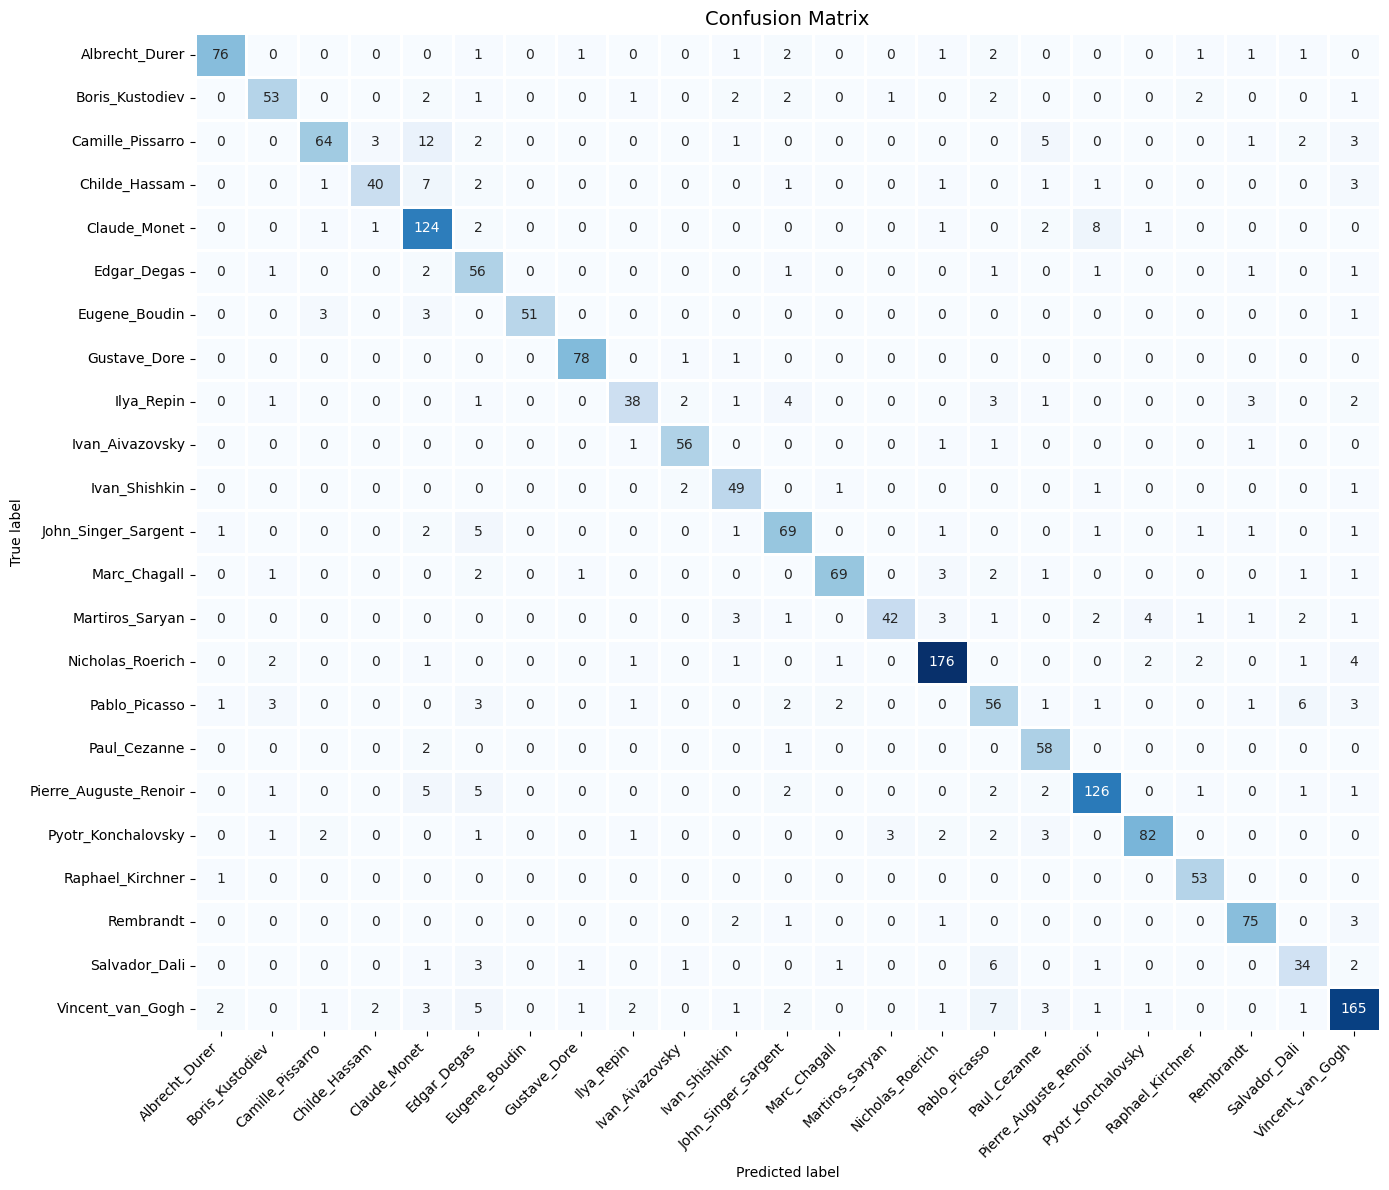


Per-class accuracy:
  Albrecht_Durer                 0.874
  Boris_Kustodiev                0.791
  Camille_Pissarro               0.688
  Childe_Hassam                  0.702
  Claude_Monet                   0.886
  Edgar_Degas                    0.875
  Eugene_Boudin                  0.879
  Gustave_Dore                   0.975
  Ilya_Repin                     0.679
  Ivan_Aivazovsky                0.933
  Ivan_Shishkin                  0.907
  John_Singer_Sargent            0.831
  Marc_Chagall                   0.852
  Martiros_Saryan                0.689
  Nicholas_Roerich               0.921
  Pablo_Picasso                  0.700
  Paul_Cezanne                   0.951
  Pierre_Auguste_Renoir          0.863
  Pyotr_Konchalovsky             0.845
  Raphael_Kirchner               0.981
  Rembrandt                      0.915
  Salvador_Dali                  0.680
  Vincent_van_Gogh               0.833


In [ ]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(14, 12))
sns.heatmap(
    cm,
    cmap='Blues',
    annot=True,
    fmt='d',
    linewidths=1,
    cbar=False,
    annot_kws={'fontsize': 10},
    yticklabels=class_names,
    xticklabels=class_names,
)
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('True label')
plt.xlabel('Predicted label')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()

# save figure for the report
plt.savefig(FIGURES_DIR + '/confusion_matrix_pretrained.png', dpi=150)
plt.show()

# Per-class accuracy
print('\nPer-class accuracy:')
for i, name in enumerate(class_names):
    per_class_acc = cm[i, i] / cm[i].sum() if cm[i].sum() > 0 else 0
    print(f'  {name:<30} {per_class_acc:.3f}')

## 6. Grad-CAM
> Visualises which regions of the painting the model focuses on.
> Reference: https://keras.io/examples/vision/grad_cam/
> For VGG16, the last conv layer is `block5_conv3`.

In [13]:
for layer in model.layers[1].layers:
    if "stage_3_block_2" in layer.name:
        print(layer)

<Conv2D name=convnext_large_stage_3_block_2_depthwise_conv, built=True>
<LayerNormalization name=convnext_large_stage_3_block_2_layernorm, built=True>
<Dense name=convnext_large_stage_3_block_2_pointwise_conv_1, built=True>
<Activation name=convnext_large_stage_3_block_2_gelu, built=True>
<Dense name=convnext_large_stage_3_block_2_pointwise_conv_2, built=True>
<LayerScale name=convnext_large_stage_3_block_2_layer_scale, built=True>
<Activation name=convnext_large_stage_3_block_2_identity, built=True>


In [14]:
model.layers[1].get_layer("convnext_large_stage_3_block_2_depthwise_conv")

<Conv2D name=convnext_large_stage_3_block_2_depthwise_conv, built=True>

In [18]:
grad_model = keras.models.Model(
    model.inputs, 
    [model.layers[1].get_layer("convnext_large_stage_3_block_2_depthwise_conv").output, model.output]
)

In [19]:
for images, labels in test_ds.take(1):
    img_batch = tf.expand_dims(images[0], axis=0)
    img_np = (images[0].numpy()).astype('uint8')

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_batch, training=False)
        tape.watch(conv_outputs)
        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    heatmap = heatmap.numpy()

    heatmap_res = cv2.resize(heatmap, (128, 128))
    heatmap_color = cv2.applyColorMap(np.uint8(255 * heatmap_res), cv2.COLORMAP_JET)
    heatmap_color = cv2.cvtColor(heatmap_color, cv2.COLOR_BGR2RGB)
    overlay = cv2.addWeighted(img_np, 0.6, heatmap_color, 0.4, 0)

    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(img_np)
    plt.title(f"True: {class_names[np.argmax(labels[0])]}")
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(overlay)
    plt.title(f"Predicted: {class_names[pred_index]}")
    plt.axis('off')
    plt.tight_layout()
    plt.show()

ResourceExhaustedError: Exception encountered when calling Activation.call().

[1m{{function_node __wrapped__Mul_device_/job:localhost/replica:0/task:0/device:GPU:0}} failed to allocate memory [Op:Mul] name: [0m

Arguments received by Activation.call():
  • inputs=tf.Tensor(shape=(1, 32, 32, 3072), dtype=float32)

## 7. Misclassified samples
> Show the worst predictions — highest confidence but wrong.
> Ask: are these images ambiguous? Similar to another class? Possibly mislabelled?

In [ ]:
# Collect all misclassified images with their confidence
wrong_imgs, wrong_true, wrong_pred, wrong_conf = [], [], [], []

for images, labels in test_ds:
    probs        = model.predict(images, verbose=0)
    pred_classes = np.argmax(probs, axis=1)
    true_classes = np.argmax(labels.numpy(), axis=1)

    for i in range(len(true_classes)):
        if pred_classes[i] != true_classes[i]:
            wrong_imgs.append(images[i].numpy().astype('uint8'))
            wrong_true.append(true_classes[i])
            wrong_pred.append(pred_classes[i])
            wrong_conf.append(probs[i][pred_classes[i]])   # confidence of wrong prediction

# Sort by highest confidence wrong prediction (worst mistakes)
sorted_idx  = np.argsort(wrong_conf)[::-1]
n_show      = min(10, len(sorted_idx))

print(f'Total misclassified: {len(wrong_imgs)} / {len(y_true)} ({len(wrong_imgs)/len(y_true)*100:.1f}%)')

cols = 5
rows = (n_show + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, rows * 4))
axes = axes.flatten()

for i, idx in enumerate(sorted_idx[:n_show]):
    axes[i].imshow(wrong_imgs[idx])
    axes[i].set_title(
        f'True: {class_names[wrong_true[idx]]}\nPred: {class_names[wrong_pred[idx]]}\nConf: {wrong_conf[idx]:.2f}',
        fontsize=8, color='red'
    )
    axes[i].axis('off')

for j in range(n_show, len(axes)):
    axes[j].axis('off')

plt.suptitle('Most Confident Wrong Predictions', fontsize=12)
plt.tight_layout()
plt.savefig(FIGURES_DIR + '/misclassified_pretrained.png', dpi=150)
plt.show()

In [ ]:
print(f"{'Class Name':<30} | {'Total Errors'}")
print("-" * 45)

for i, name in enumerate(class_names):
    # Total images in this class minus the ones on the diagonal (correct)
    total_in_class = cm[i].sum()
    correct_preds = cm[i, i]
    errors = total_in_class - correct_preds
    
    print(f"{name:<30} | {int(errors)}")

In [ ]:
# Calculate error counts
error_counts = []
for i in range(len(class_names)):
    error_counts.append(cm[i].sum() - cm[i, i]) #cm is the confusion matrix

# Sort by error count
error_val_df = pd.DataFrame({'Artist': class_names, 'Errors': error_counts})
error_val_df = error_val_df.sort_values('Errors', ascending=False)

# Create Plot
plt.figure(figsize=(12, 8))
sns.barplot(x='Errors', y='Artist', data=error_val_df, palette='Reds_r') 

plt.title('Total Misclassifications per Artist (Class)', fontsize=14)
plt.xlabel('Number of Errors')
plt.ylabel('Artist (Class)')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Save for your project folder
plt.savefig(FIGURES_DIR + '/errors_by_class_pretrained.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# percentage of errors for each class

per_class_error_pct = []

for i in range(len(class_names)):
    total_samples = cm[i].sum()
    if total_samples > 0:
        # (Total images - correct predictions / total images) * 100
        error_pct = (1 - (cm[i,i]) / total_samples) * 100
        per_class_error_pct.append(error_pct)
    else:
        per_class_error_pct.append(0)

# Save as DataFrame to ease the visualization

error_df = pd.DataFrame({
    'Artists (Class)': class_names,
    'Error %': per_class_error_pct
}).sort_values('Error %', ascending=False) # Order by the classes with the bigger % of error

# Visualization
plt.figure(figsize=(12, 8))
ax = sns.barplot(data=error_df, x='Error %', y='Artists (Class)', palette='magma')

# To appear the % on the bars. 
for p in ax.patches:
    ax.annotate(f'{p.get_width():.1f}%', 
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points', 
                va='center', fontsize=9)

plt.title('Error Rate for each Artist (Class) (%)', fontsize=14)
plt.xlabel('Error Rate (%)')
plt.ylabel('Artist (Class)')
plt.xlim(0, 110) # text
plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.savefig(FIGURES_DIR + '/error_percentage_by_class_pretrained.png', dpi=150, bbox_inches='tight')
plt.show()